In [1]:
!pip install transformers torch datasets rouge-score matplotlib seaborn plotly SentencePiece --quiet

  Preparing metadata (setup.py) ... done


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import T5Tokenizer, T5ForConditionalGeneration, T5Config, pipeline
from rouge_score import rouge_scorer
import warnings
warnings.filterwarnings("ignore")
plt.style.use('default')
sns.set_palette("husl")

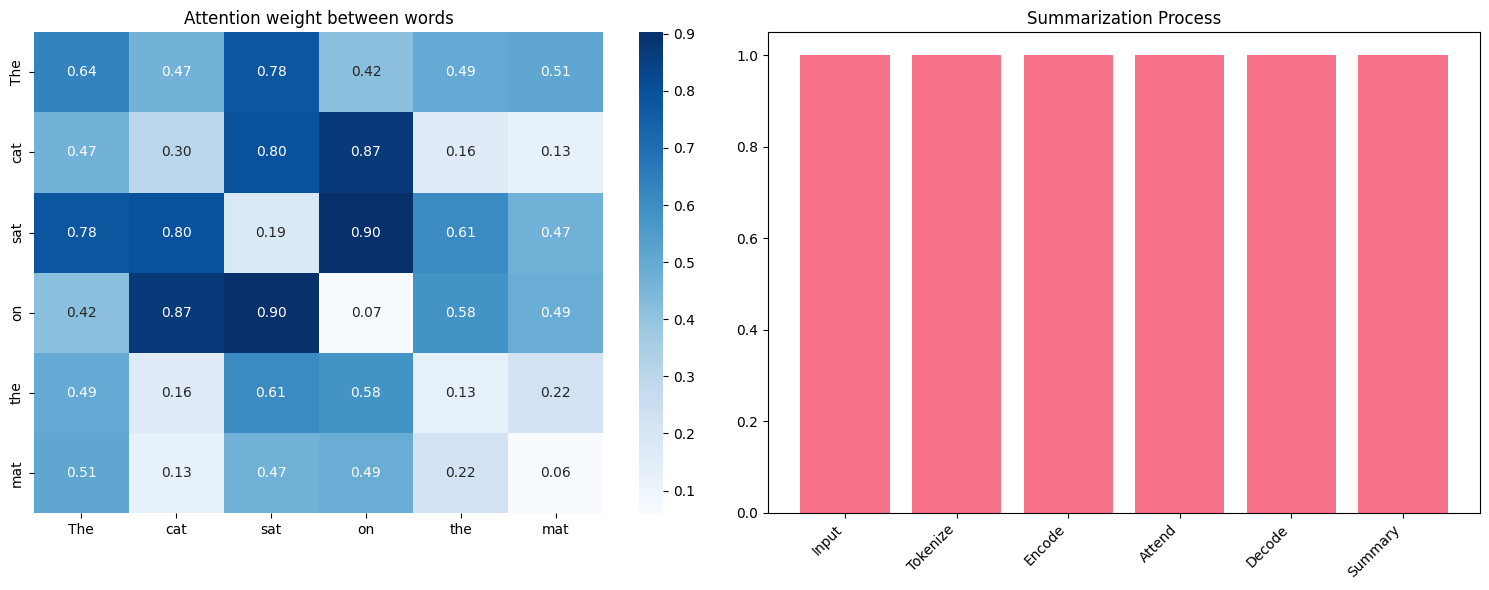

In [3]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))
input_text ='The cat sat on the mat'
words = input_text.split()
attention_matrix = np.random.rand(len(words),len(words))
attention_matrix = (attention_matrix + attention_matrix.T)/2
sns.heatmap(attention_matrix,annot=True,fmt='.2f',cmap='Blues',ax=ax1,xticklabels=words,yticklabels=words)
ax1.set_title('Attention weight between words')
process_steps = ['Input','Tokenize','Encode','Attend','Decode','Summary']
ax2.bar(range(len(process_steps)),[1]*len(process_steps))
ax2.set_xticks(range(len(process_steps)))
ax2.set_xticklabels(process_steps,rotation=45,ha='right')
ax2.set_title('Summarization Process')
plt.tight_layout()
plt.show()

In [4]:
print('loading T5-small model')
model_name='t5-small'
tokenizer=T5Tokenizer.from_pretrained(model_name)
model=T5ForConditionalGeneration.from_pretrained(model_name,return_dict=True)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"model loaded:{model_name}")
print(f"device:{device}")
print(f"model parameters:{model.num_parameters():,}")

loading T5-small model


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

model loaded:t5-small
device:cpu
model parameters:60,506,624


In [5]:
sample_texts={
"al":
"""Artificial intelligence (AI) is intelligence demonstrated by machines,
 as opposed to natural intelligence displayed by animals including humans.
 Leading Al textbooks define the field as the study of intelligent agents:
  any system that perceives its environment and takes actions that maximize
   its chance of achieving its goals."""
,
"climate":
"""Climate change refers to long-term shifts in global temperatures and
 weather patterns. While climate variations occur naturally, scientific
 evidence shows that human activities have been the dominant driver since
  the mid-20t"""
}

for key, text in sample_texts.items():
  print(f"{key.upper()} TEXT:")
  print(f"Length: {len(text.split())} words")
  print(f"Preview: {text[:100]}...")

print()

AL TEXT:
Length: 47 words
Preview: Artificial intelligence (AI) is intelligence demonstrated by machines,
 as opposed to natural intell...
CLIMATE TEXT:
Length: 31 words
Preview: Climate change refers to long-term shifts in global temperatures and
 weather patterns. While climat...



In [7]:
def Summarization_text(text,max_length=30,min_length=10):
  input_text = f"summarize: {text.strip()}"
  inputs = tokenizer.encode(
      input_text,
      return_tensors='pt',
      max_length=512,
      truncation=True
  ).to(device)
  with torch.no_grad():
   summary_ids = model.generate(
      inputs,
      max_length=max_length,
      min_length=min_length,
      length_penalty=1.0,
      num_beams=4,
      early_stopping=True,
      no_repeat_ngram_size=2
   )
   summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
   return {
       'summary':summary,
       'input_length':len(input_text.split()),
       'summary_length':len(summary.split()),
       'compression_ratio':round(len(input_text.split())/max(len(summary.split()),1,2))
   }
   for key, text in sample_texts.items():
    print(f"Summarizing {key.upper()}...")
    result = summarize_text(text)
    print(f"Original: {result['original_words']} words")
    print(f"Summary: {result['summary_words']} words")
    print(f"Summary: {result['summary']}")
    print()

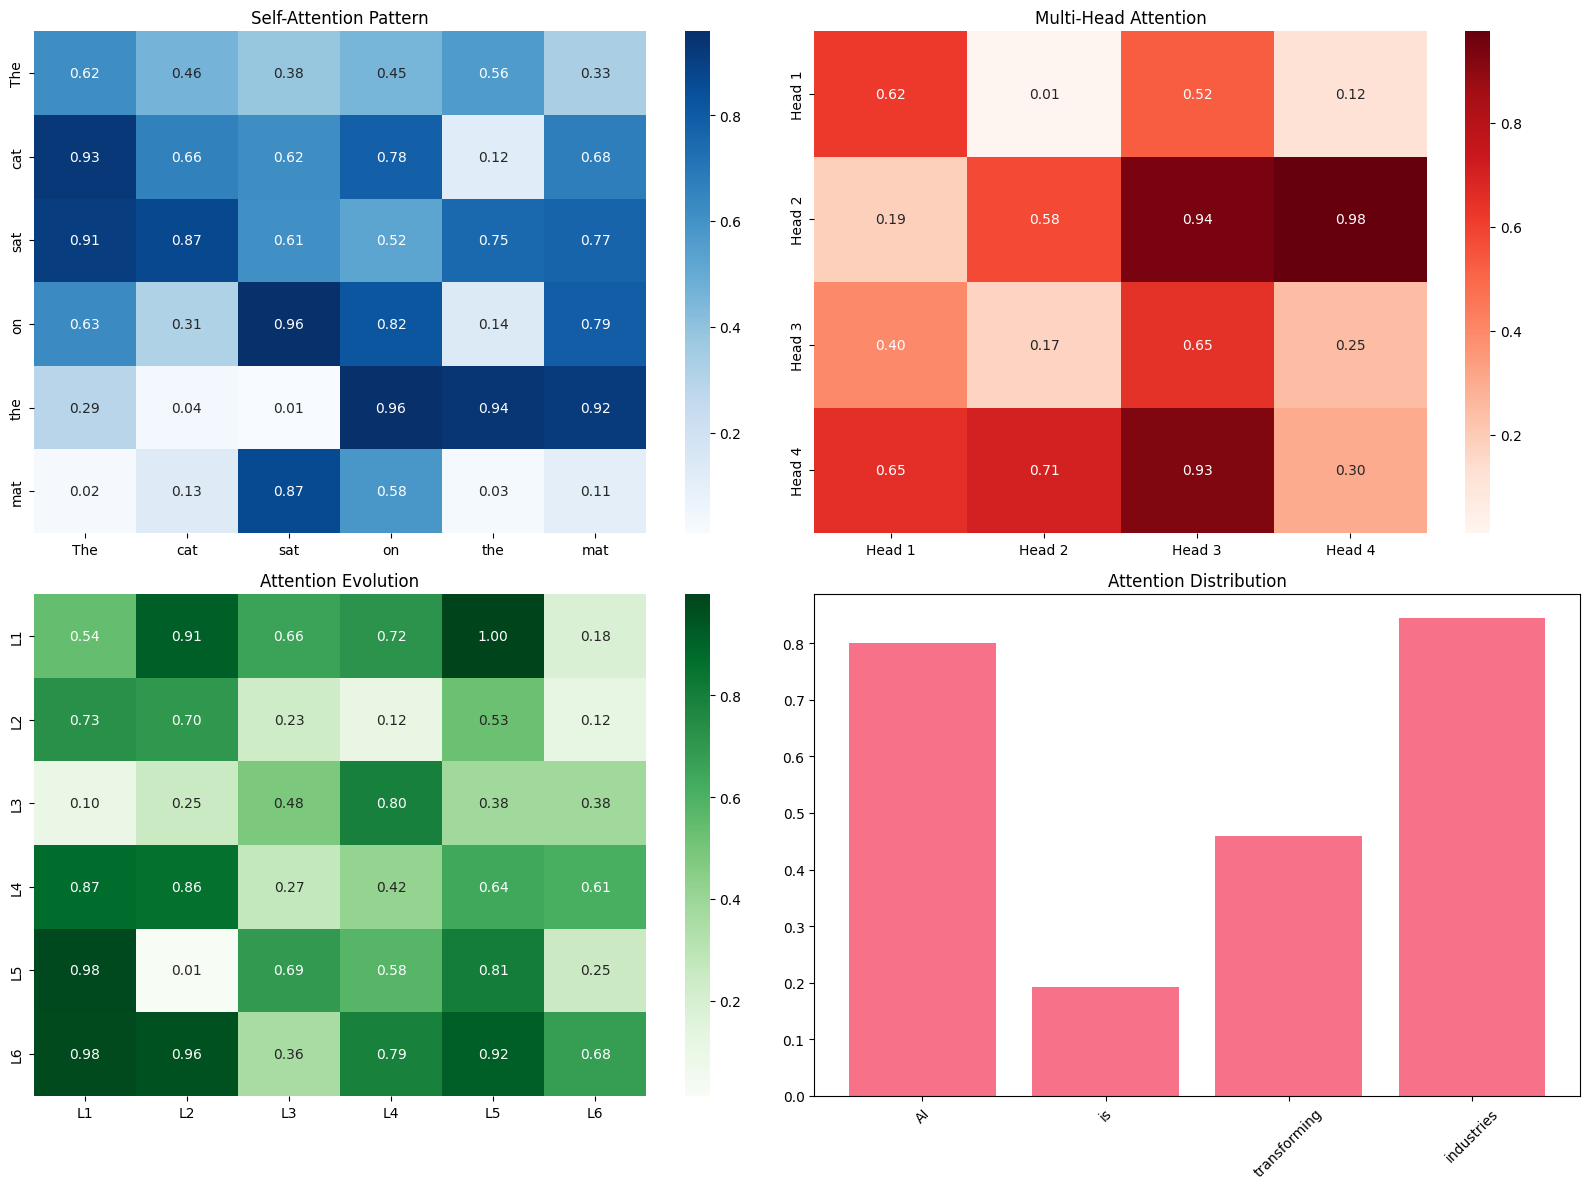

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

words = ["The", "cat", "sat", "on", "the", "mat"]
attention = np.random.rand(6, 6)
sns.heatmap(attention, annot=True, fmt='.2f',
            xticklabels=words, yticklabels=words, ax=axes[0,0], cmap='Blues')
axes[0,0].set_title('Self-Attention Pattern')

heads = ['Head 1', 'Head 2', 'Head 3', 'Head 4']
multi_head = np.random.rand(4, 4)
sns.heatmap(multi_head, annot=True, fmt='.2f',
            xticklabels=heads, yticklabels=heads, ax=axes[0,1], cmap='Reds')
axes[0,1].set_title('Multi-Head Attention')

layers = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']
evolution = np.random.rand(6, 6)
sns.heatmap(evolution, annot=True, fmt='.2f',
            xticklabels=layers, yticklabels=layers, ax=axes[1,0], cmap='Greens')
axes[1,0].set_title('Attention Evolution')

tokens = ['AI', 'is', 'transforming', 'industries']
distribution = np.random.rand(4)
axes[1,1].bar(tokens, distribution)
axes[1,1].set_title('Attention Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch

model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_text = "summarize: Artificial intelligence is transforming industries worldwide. From healthcare to finance, AI applications are revolutionizing how we work and live. Machine learning algorithms can now diagnose diseases, predict market trends, and even drive cars."

print("Generating summary...")
inputs = tokenizer.encode(test_text, return_tensors="pt", max_length=512, truncation=True).to(device)
outputs = model.generate(
    inputs,
    max_length=50,
    min_length=10,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Summary: {summary}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Generating summary...
Summary: artificial intelligence is transforming industries worldwide. from healthcare to finance, AI applications are revolutionizing how we work and live.


In [13]:
class SimpleSummarizer:
    """A simple summarizer class for educational purposes"""

    def __init__(self, model_name="t5-small"):
        print(f"Loading {model_name}...")
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5ForConditionalGeneration.from_pretrained(model_name)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self.model.to(self.device)
        print(f"{model_name} loaded successfully!")

    def summarize(self, text, max_length=50, min_length=10):
        """Summarize text with statistics"""
        input_text = f"summarize: {text.strip()}"

        inputs = self.tokenizer.encode(
            input_text,
            return_tensors="pt",
            max_length=512,
            truncation=True
        ).to(self.device)

        # Generate summary
        with torch.no_grad():
            summary_ids = self.model.generate(
                inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=2
            )

        # Decode summary
        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return {
            'summary': summary,
            'original_words': len(text.split()),
            'summary_words': len(summary.split()),
            'compression_ratio': round(len(text.split()) / max(len(summary.split()), 1), 2)
        }

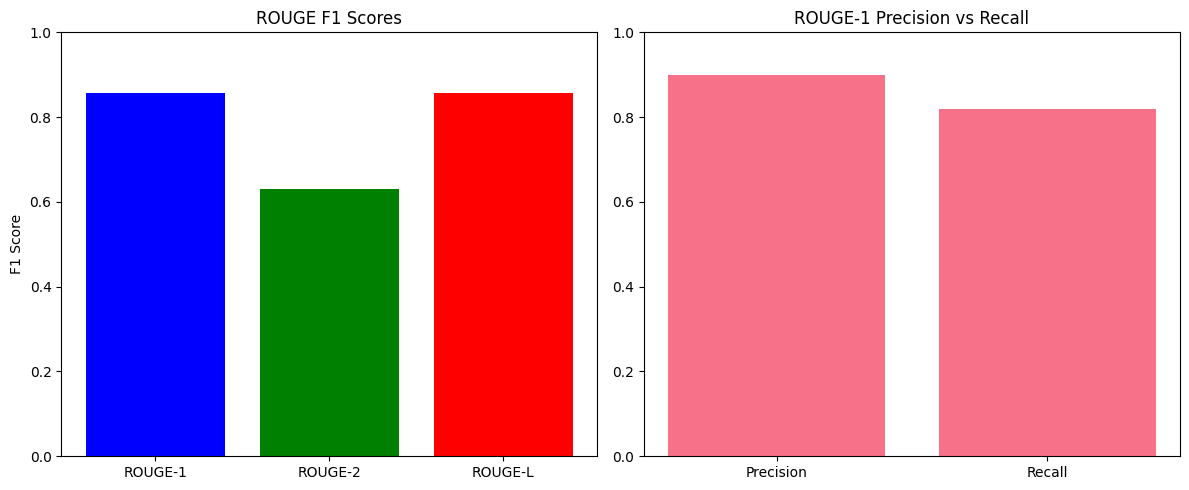

ROUGE Scores:
rouge1: F1=0.857
rouge2: F1=0.632
rougeL: F1=0.857


In [14]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
reference = "AI systems learn from data to make predictions without explicit programming."
generated = "AI learns from data to make predictions without being programmed."
scores = scorer.score(reference, generated)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
f1_scores = [scores['rouge1'].fmeasure, scores['rouge2'].fmeasure, scores['rougeL'].fmeasure]
ax1.bar(metrics, f1_scores, color=['blue', 'green', 'red'])
ax1.set_ylabel('F1 Score')
ax1.set_title('ROUGE F1 Scores')
ax1.set_ylim(0, 1)
ax2.bar(['Precision', 'Recall'], [scores['rouge1'].precision, scores['rouge1'].recall])
ax2.set_title('ROUGE-1 Precision vs Recall')
ax2.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print("ROUGE Scores:")
for metric, score in scores.items():
    print(f"{metric}: F1={score.fmeasure:.3f}")

In [18]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

text_to_summarize = "summarize: Plants are remarkable organisms that produce their own food using a method called photosynthesis. This process involves converting sunlight, carbon dioxide, and water into glucose, which provides energy for growth. Plants play a crucial role in sustaining life on Earth by generating oxygen and serving as the foundation of most ecosystems."

inputs = tokenizer.encode(text_to_summarize, return_tensors="pt", max_length=512, truncation=True).to(device)
outputs = model.generate(
    inputs,
    max_length=40,
    min_length=10,
    num_beams=4,
    early_stopping=True
)

summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Summary: {summary}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Summary: photosynthesis involves converting sunlight, carbon dioxide, and water into glucose, which provides energy for growth. plants play a crucial role in sustaining life on earth by generating oxygen and


In [19]:
models_to_compare =["t5-small", "t5-base"]
test_text = """Deep learning is a subset of machine learning that uses neural networks
with multiple layers. These networks can learn complex patterns in data
and have achieved remarkable success in tasks like image recognition,
natural language processing, and game playing."""

for model_name in models_to_compare:
    print(f"\nTesting {model_name} ... ")
    try:
        summarizer = pipeline("summarization", model=model_name)
        summary = summarizer(test_text, max_length=30, min_length=5)
        print(f"Summary: {summary[0]['summary_text']}")
    except Exception as e:
        print(f"Error loading {model_name} : {e}")


Testing t5-small ... 
Error loading t5-small : "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'image-to-image', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'question-answering', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'visual-question-answering', 'vqa', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection', 'translation_XX_to_YY']"

Testing t5-base ... 


config.json: 0.00B [00:00, ?B/s]

Error loading t5-base : "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'image-to-image', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'question-answering', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'visual-question-answering', 'vqa', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection', 'translation_XX_to_YY']"
